# Canonical Model With Housekeeping Sector

Solve for lambda and Y with built-in Python library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp
from joblib import Parallel, delayed
import pandas as pd
import time

# ============================================================
# Parameters
# ============================================================
a = 20.0
k = 0.11
theta_Q = 0.50      # <-- replace by your fitted/fixed housekeeping fraction
N = 120

b_min, b_max = 1e-3, 1e3
b_vals = np.logspace(np.log10(b_min), np.log10(b_max), N)

label_size = 14
title_size = 16
tick_size = 13


### Softmax transformation

In [3]:
# ============================================================
# Softmax partition with fixed housekeeping fraction
# theta_P + theta_R = 1 - theta_Q
# ============================================================
def softmax_partition_HK(u, theta_Q=theta_Q):
    """
    Map a single unconstrained variable u to (theta_P, theta_R)
    with theta_P, theta_R > 0 and theta_P + theta_R = 1 - theta_Q.
    """
    u_val = float(np.atleast_1d(u)[0])
    logZ = logsumexp([u_val, 0.0])

    frac_P = np.exp(u_val - logZ)
    frac_R = np.exp(-logZ)

    scale = 1.0 - theta_Q
    theta_P = scale * frac_P
    theta_R = scale * frac_R
    return theta_P, theta_R

# ============================================================
# Exact steady state for the HK model
#
# Y1* = 1/2 [ sqrt((a theta_R/(b theta_P) + k - 1)^2 + 4k)
#             - (a theta_R/(b theta_P) + k - 1) ]
#
# Y2* = (a theta_R / b) * Y1/(k + Y1)
# Y3* = (a theta_Q theta_R / theta_P) * Y1/(k + Y1)
# Y4* = (a theta_R^2 / theta_P)       * Y1/(k + Y1)
#
# lambda = b Y2*
# ============================================================
def BioSystemHK(theta, b_val, a=a, k=k, theta_Q=theta_Q):
    theta_P, theta_R = map(float, theta)

    if theta_P <= 0.0 or theta_R <= 0.0 or theta_Q <= 0.0 or theta_Q >= 1.0:
        return np.full(8, np.nan)

    z = a * theta_R / (b_val * theta_P)
    sqrt_term = np.sqrt((z + k - 1.0)**2 + 4.0 * k)

    Y1 = 0.5 * (sqrt_term - (z + k - 1.0))
    frac = Y1 / (k + Y1)

    Y2 = (a * theta_R / b_val) * frac
    Y3 = (a * theta_Q * theta_R / theta_P) * frac
    Y4 = (a * theta_R**2 / theta_P) * frac
    lambda_val = b_val * Y2

    return np.array([b_val, theta_P, theta_R, Y1, Y2, Y3, Y4, lambda_val])

def objective_softmax_HK(u, b_val):
    return -BioSystemHK(softmax_partition_HK(u), b_val)[-1]

# ============================================================
# Numerical optimization for each b
# ============================================================
def optimize_for_b_softmax_HK(b_val, tol=1e-10, maxiter=3000):
    # One-dimensional optimization because theta_Q is fixed
    result = minimize(
        lambda u: objective_softmax_HK(u, b_val),
        x0=np.array([0.0]),
        method="Powell",
        tol=tol,
        options={
            "xtol": tol,
            "ftol": tol,
            "maxiter": maxiter,
            "disp": False
        }
    )

    if np.isfinite(result.fun):
        bio_result = BioSystemHK(softmax_partition_HK(result.x), b_val)
        if np.all(np.isfinite(bio_result)) and bio_result[-1] >= 0.0:
            return bio_result

    return None


# ============================================================
# Parallel execution
# ============================================================
start = time.time()
results = Parallel(n_jobs=-1)(
    delayed(optimize_for_b_softmax_HK)(b) for b in b_vals
)
results = np.array([r for r in results if r is not None])

print(f"Optimization completed in {time.time() - start:.2f} seconds.")

# Unpack
(b_arr, thetaP_arr, thetaR_arr, Y1_arr, Y2_arr, Y3_arr, Y4_arr, lambda_arr) = results.T

Optimization completed in 2.64 seconds.


In [4]:
# ============================================================
# DataFrame
# ============================================================
df = pd.DataFrame({
    "b": b_arr,
    "theta_Q": theta_Q,
    "theta_P*": thetaP_arr,
    "theta_R*": thetaR_arr,
    "theta_P* + theta_R*": thetaP_arr + thetaR_arr,
    "1 - theta_Q": (1.0 - theta_Q) * np.ones_like(b_arr),
    "Y1*": Y1_arr,
    "Y2*": Y2_arr,
    "Y3*": Y3_arr,
    "Y4*": Y4_arr,
    "Sum_Y": Y1_arr + Y2_arr + Y3_arr + Y4_arr,
    "lambda*": lambda_arr
})

try:
    from IPython.display import display
    display(df)
except Exception:
    print(df.head())

,b,theta_Q,theta_P*,theta_R*,theta_P* + theta_R*,1 - theta_Q,Y1*,Y2*,Y3*,Y4*,Sum_Y,lambda*
0,0.001000,0.5,0.498805,0.001195,0.5,0.5,0.002340,0.497638,0.000499,0.000001,0.500478,0.000498
1,0.001123,0.5,0.498733,0.001267,0.5,0.5,0.002479,0.497496,0.000560,0.000001,0.500537,0.000559
2,0.001261,0.5,0.498655,0.001345,0.5,0.5,0.002627,0.497345,0.000629,0.000002,0.500603,0.000627
3,0.001417,0.5,0.498573,0.001427,0.5,0.5,0.002784,0.497185,0.000706,0.000002,0.500677,0.000704
4,0.001591,0.5,0.498486,0.001514,0.5,0.5,0.002949,0.497016,0.000793,0.000002,0.500761,0.000791
...,...,...,...,...,...,...,...,...,...,...,...,...
115,628.520327,0.5,0.036101,0.463899,0.5,0.5,0.650260,0.012626,109.909472,101.973891,212.546248,7.935581
116,705.894009,0.5,0.033664,0.466336,0.5,0.5,0.663343,0.011333,118.821973,110.821885,230.318535,8.000089
117,792.792739,0.5,0.031399,0.468601,0.5,0.5,0.676181,0.010168,128.360570,120.299849,249.346769,8.060721
118,890.389094,0.5,0.029293,0.470707,0.5,0.5,0.688759,0.009117,138.562628,130.444935,269.705439,8.117694


### Plot the result

max |theta_P* - theta_P^TP| = 1.267337e-08
max |theta_R* - theta_R^TP| = 1.267337e-08
max relative error in lambda (using TP partition) = 1.987842e-12


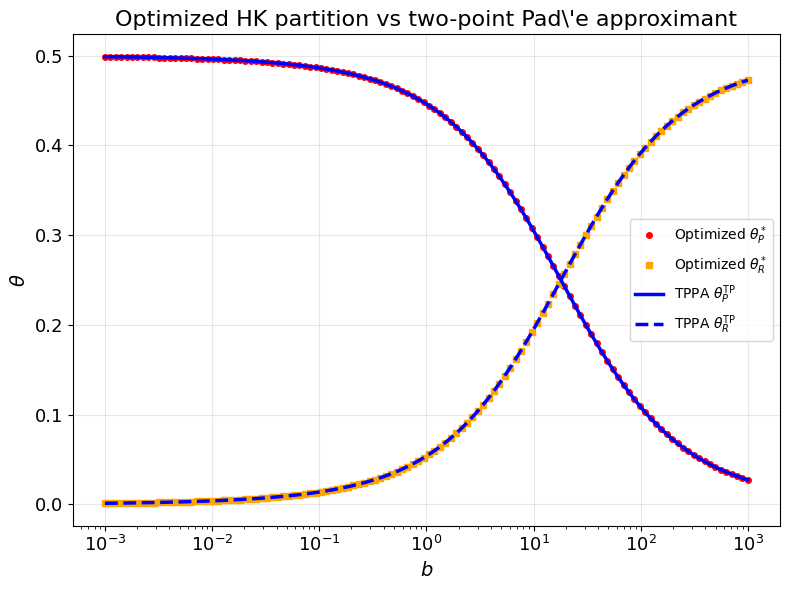

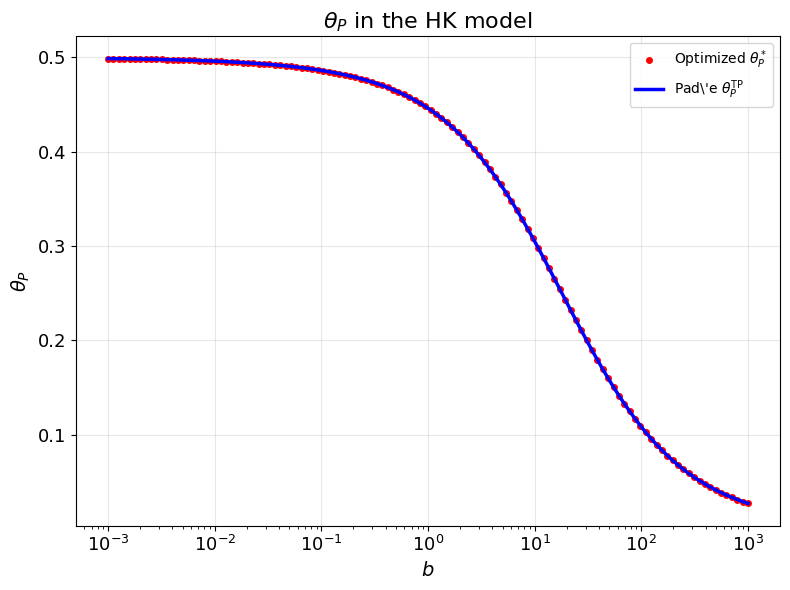

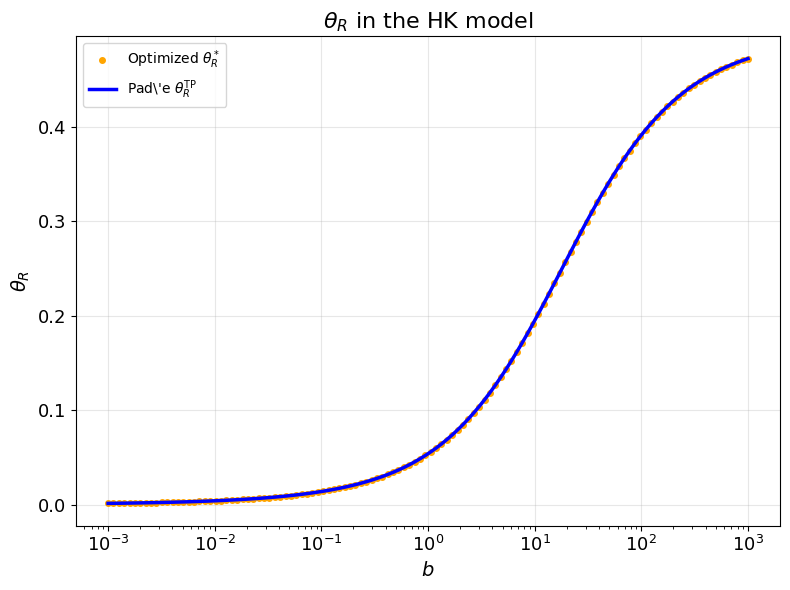

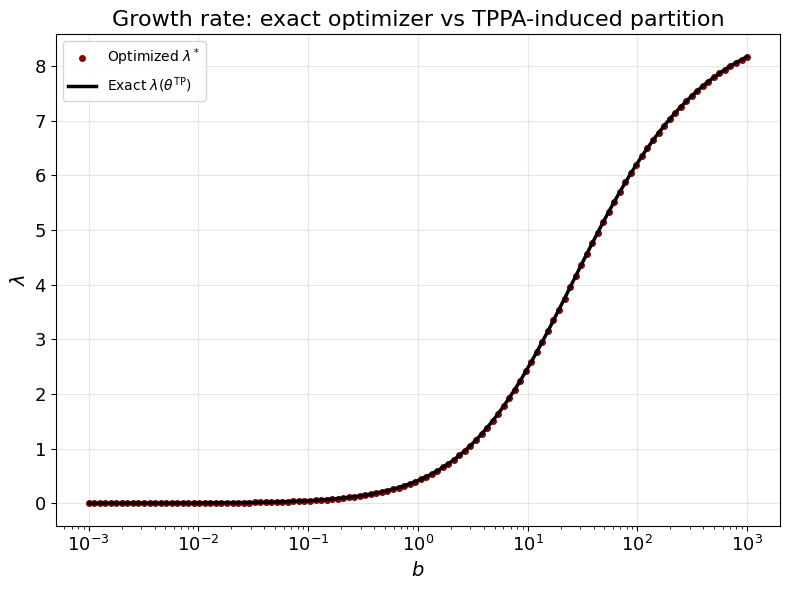

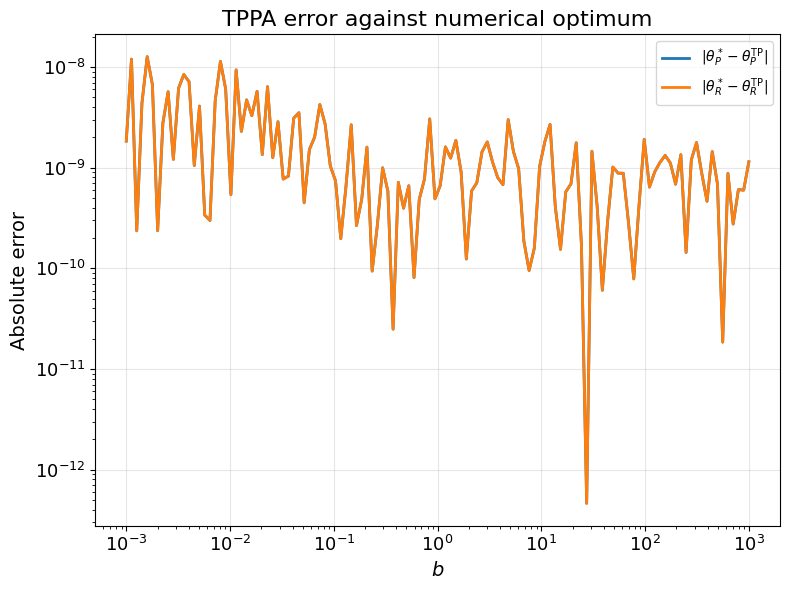

In [5]:
# ============================================================
# Two-point Pade approximant from the HK formula
#
# theta_P^TP = (1-theta_Q) * [1 + sqrt(k/a) sqrt(b)]
#              / [1 + 2 sqrt(k/a) sqrt(b) + ((1+k)/a) b]
#
# theta_R^TP = (1-theta_Q) * [sqrt(k/a) sqrt(b) + ((1+k)/a) b]
#              / [1 + 2 sqrt(k/a) sqrt(b) + ((1+k)/a) b]
# ============================================================
A = np.sqrt(k / a)

def pade_two_point_HK(b, a=a, k=k, theta_Q=theta_Q):
    sqb = np.sqrt(b)
    denom = 1.0 + 2.0 * A * sqb + ((1.0 + k) / a) * b

    theta_P_tp = (1.0 - theta_Q) * (1.0 + A * sqb) / denom
    theta_R_tp = (1.0 - theta_Q) * (A * sqb + ((1.0 + k) / a) * b) / denom
    return theta_P_tp, theta_R_tp

thetaP_TP_arr, thetaR_TP_arr = pade_two_point_HK(b_arr)

# Evaluate the exact growth rate at the TPPA-predicted partition
lambda_TP_arr = np.array([
    BioSystemHK((thP, thR), b)[-1]
    for b, thP, thR in zip(b_arr, thetaP_TP_arr, thetaR_TP_arr)
])

# ============================================================
# Optional error diagnostics
# ============================================================
thetaP_abs_err = np.abs(thetaP_arr - thetaP_TP_arr)
thetaR_abs_err = np.abs(thetaR_arr - thetaR_TP_arr)
lambda_rel_err = np.abs(lambda_arr - lambda_TP_arr) / np.maximum(np.abs(lambda_arr), 1e-14)

print(f"max |theta_P* - theta_P^TP| = {thetaP_abs_err.max():.6e}")
print(f"max |theta_R* - theta_R^TP| = {thetaR_abs_err.max():.6e}")
print(f"max relative error in lambda (using TP partition) = {lambda_rel_err.max():.6e}")

# ============================================================
# Plot 1: optimized partition vs TPPA
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_arr, 'o', ms=4, label=r'Optimized $\theta_P^*$', color='red')
plt.plot(b_arr, thetaR_arr, 's', ms=4, label=r'Optimized $\theta_R^*$', color='orange')

plt.plot(b_arr, thetaP_TP_arr, '-', lw=2.5, label=r'TPPA $\theta_P^{\mathrm{TP}}$', color='blue')
plt.plot(b_arr, thetaR_TP_arr, '--', lw=2.5, label=r'TPPA $\theta_R^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta$', fontsize=label_size)
plt.title(r'Optimized HK partition vs two-point Pad\'e approximant', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: theta_P only
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_arr, 'o', ms=4, label=r'Optimized $\theta_P^*$', color='red')
plt.plot(b_arr, thetaP_TP_arr, '-', lw=2.5, label=r'Pad\'e $\theta_P^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_P$', fontsize=label_size)
plt.title(r'$\theta_P$ in the HK model', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: theta_R only
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaR_arr, 'o', ms=4, label=r'Optimized $\theta_R^*$', color='orange')
plt.plot(b_arr, thetaR_TP_arr, '-', lw=2.5, label=r'Pad\'e $\theta_R^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_R$', fontsize=label_size)
plt.title(r'$\theta_R$ in the HK model', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: exact optimized growth rate vs TPPA-induced growth rate
# Here lambda_TP_arr is the exact lambda evaluated at the TPPA partition.
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, lambda_arr, 'o', ms=4, label=r'Optimized $\lambda^*$', color='darkred')
plt.plot(b_arr, lambda_TP_arr, '-', lw=2.5,
         label=r'Exact $\lambda(\theta^{\mathrm{TP}})$', color='black')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\lambda$', fontsize=label_size)
plt.title(r'Growth rate: exact optimizer vs TPPA-induced partition', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 5: absolute partition error of TPPA
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_abs_err, lw=2, label=r'$|\theta_P^*-\theta_P^{\mathrm{TP}}|$')
plt.plot(b_arr, thetaR_abs_err, lw=2, label=r'$|\theta_R^*-\theta_R^{\mathrm{TP}}|$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'Absolute error', fontsize=label_size)
plt.title(r'TPPA error against numerical optimum', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Changing the Amount of Proteome Allocated to Housekeeping

All theta_Q optimizations completed in 1.47 seconds.


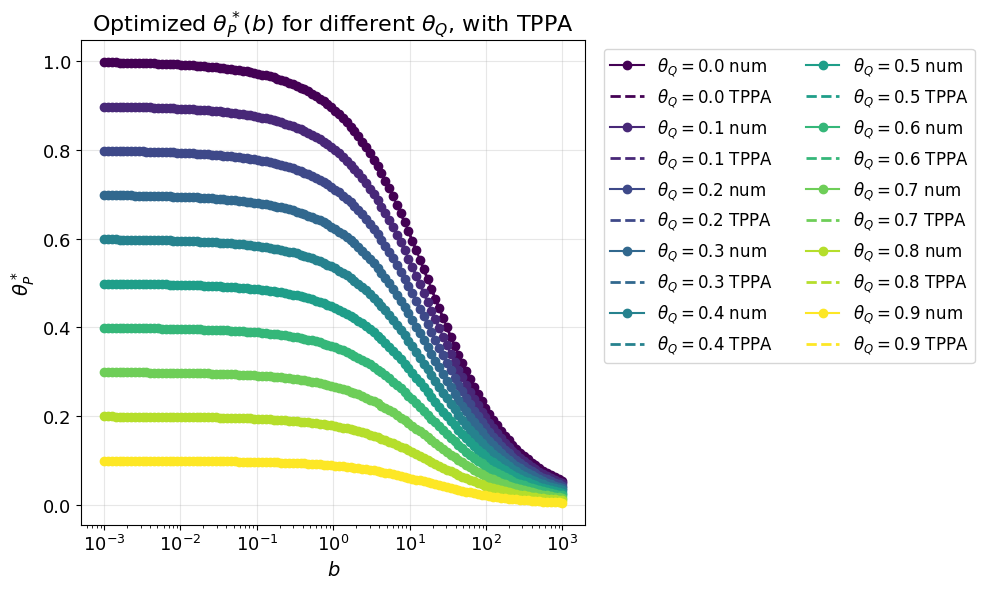

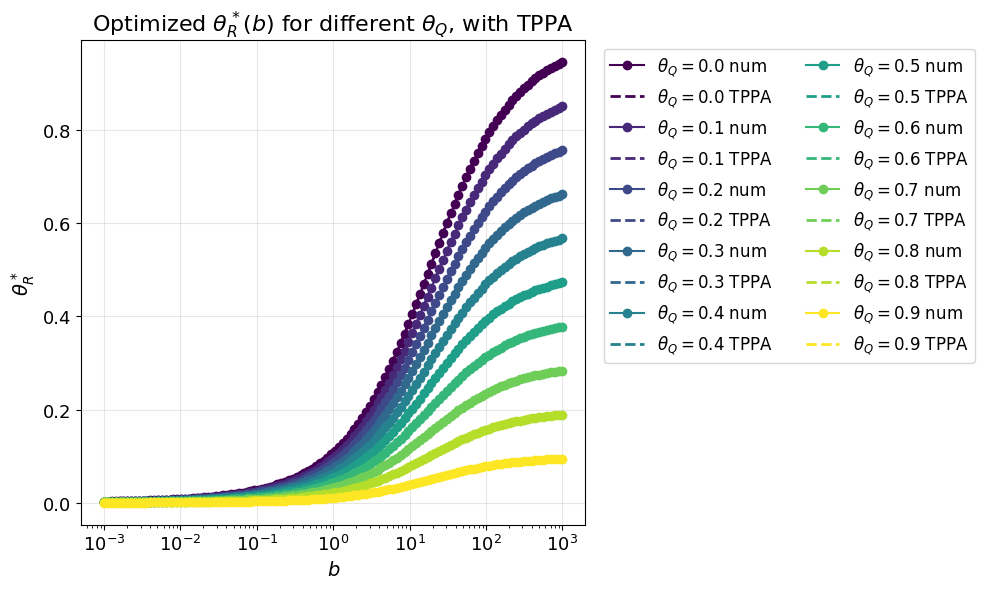

In [6]:
# ============================================================
# Multi-theta_Q plot: numerical optimizer vs TPPA
# plotting theta_P^*(b) for theta_Q = 0.0, 0.1, ..., 0.9
# ============================================================

thetaQ_list = np.round(np.arange(0.0, 1.0, 0.1), 1)

def softmax_partition_HK_thetaQ(u, theta_Q):
    """
    theta_P + theta_R = 1 - theta_Q
    """
    u_val = float(np.atleast_1d(u)[0])
    logZ = logsumexp([u_val, 0.0])
    frac_P = np.exp(u_val - logZ)
    frac_R = np.exp(-logZ)

    scale = 1.0 - theta_Q
    theta_P = scale * frac_P
    theta_R = scale * frac_R
    return theta_P, theta_R

def BioSystemHK_thetaQ(theta, b_val, theta_Q, a=a, k=k):
    theta_P, theta_R = map(float, theta)

    if theta_P <= 0.0 or theta_R <= 0.0 or theta_Q < 0.0 or theta_Q >= 1.0:
        return np.full(8, np.nan)

    term_Y1 = (a * theta_R) / (b_val * theta_P) + k - 1.0
    Y1 = 0.5 * (np.sqrt(term_Y1**2 + 4.0 * k) - term_Y1)

    frac = Y1 / (k + Y1)
    Y2 = (a * theta_R / b_val) * frac
    Y3 = (a * theta_Q * theta_R / theta_P) * frac
    Y4 = (a * theta_R**2 / theta_P) * frac
    lambda_val = b_val * Y2

    return np.array([b_val, theta_P, theta_R, Y1, Y2, Y3, Y4, lambda_val])

def objective_softmax_HK_thetaQ(u, b_val, theta_Q):
    return -BioSystemHK_thetaQ(softmax_partition_HK_thetaQ(u, theta_Q), b_val, theta_Q)[-1]

def optimize_for_b_softmax_HK_thetaQ(b_val, theta_Q, tol=1e-10, maxiter=3000):
    result = minimize(
        lambda u: objective_softmax_HK_thetaQ(u, b_val, theta_Q),
        x0=np.array([0.0]),
        method='Powell',
        tol=tol,
        options={
            'xtol': tol,
            'ftol': tol,
            'maxiter': maxiter,
            'disp': False
        }
    )

    if np.isfinite(result.fun):
        bio_result = BioSystemHK_thetaQ(
            softmax_partition_HK_thetaQ(result.x, theta_Q),
            b_val,
            theta_Q
        )
        if np.all(np.isfinite(bio_result)) and bio_result[-1] >= 0.0:
            return bio_result
    return None

def pade_two_point_HK_thetaQ(b_arr, theta_Q, a=a, k=k):
    A = np.sqrt(k / a)
    denom = 1.0 + 2.0 * A * np.sqrt(b_arr) + ((1.0 + k) / a) * b_arr

    theta_P_tp = (1.0 - theta_Q) * (1.0 + A * np.sqrt(b_arr)) / denom
    theta_R_tp = (1.0 - theta_Q) * (A * np.sqrt(b_arr) + ((1.0 + k) / a) * b_arr) / denom
    return theta_P_tp, theta_R_tp

# store all results if you want to inspect later
multi_thetaQ_results = {}

start = time.time()
for theta_Q_i in thetaQ_list:
    results_i = Parallel(n_jobs=-1)(
        delayed(optimize_for_b_softmax_HK_thetaQ)(b, theta_Q_i) for b in b_vals
    )
    results_i = np.array([r for r in results_i if r is not None])

    if len(results_i) == 0:
        continue

    (b_arr_i, thetaP_arr_i, thetaR_arr_i, Y1_arr_i, Y2_arr_i, Y3_arr_i, Y4_arr_i, lambda_arr_i) = results_i.T
    thetaP_TP_i, thetaR_TP_i = pade_two_point_HK_thetaQ(b_arr_i, theta_Q_i)

    multi_thetaQ_results[theta_Q_i] = {
        "b": b_arr_i,
        "thetaP_num": thetaP_arr_i,
        "thetaR_num": thetaR_arr_i,
        "thetaP_tppa": thetaP_TP_i,
        "thetaR_tppa": thetaR_TP_i,
        "lambda": lambda_arr_i
    }

print(f"All theta_Q optimizations completed in {time.time() - start:.2f} seconds.")

# ============================================================
# Plot all theta_P curves in one figure
# solid = numerical optimum
# dashed = TPPA
# ============================================================
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(thetaQ_list)))

for c, theta_Q_i in zip(colors, thetaQ_list):
    if theta_Q_i not in multi_thetaQ_results:
        continue

    data_i = multi_thetaQ_results[theta_Q_i]
    plt.plot(
        data_i["b"], data_i["thetaP_num"],
        marker='o', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ num'
    )
    plt.plot(
        data_i["b"], data_i["thetaP_tppa"],
        lw=2, ls='--', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ TPPA'
    )

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_P^*$', fontsize=label_size)
plt.title(r'Optimized $\theta_P^*(b)$ for different $\theta_Q$, with TPPA', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================================
# Plot all theta_R curves in one figure
# solid = numerical optimum
# dashed = TPPA
# ============================================================
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(thetaQ_list)))

for c, theta_Q_i in zip(colors, thetaQ_list):
    if theta_Q_i not in multi_thetaQ_results:
        continue

    data_i = multi_thetaQ_results[theta_Q_i]
    plt.plot(
        data_i["b"], data_i["thetaR_num"],
        marker='o', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ num'
    )
    plt.plot(
        data_i["b"], data_i["thetaR_tppa"],
        lw=2, ls='--', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ TPPA'
    )

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_R^*$', fontsize=label_size)
plt.title(r'Optimized $\theta_R^*(b)$ for different $\theta_Q$, with TPPA', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Organize Everything Into One Plot

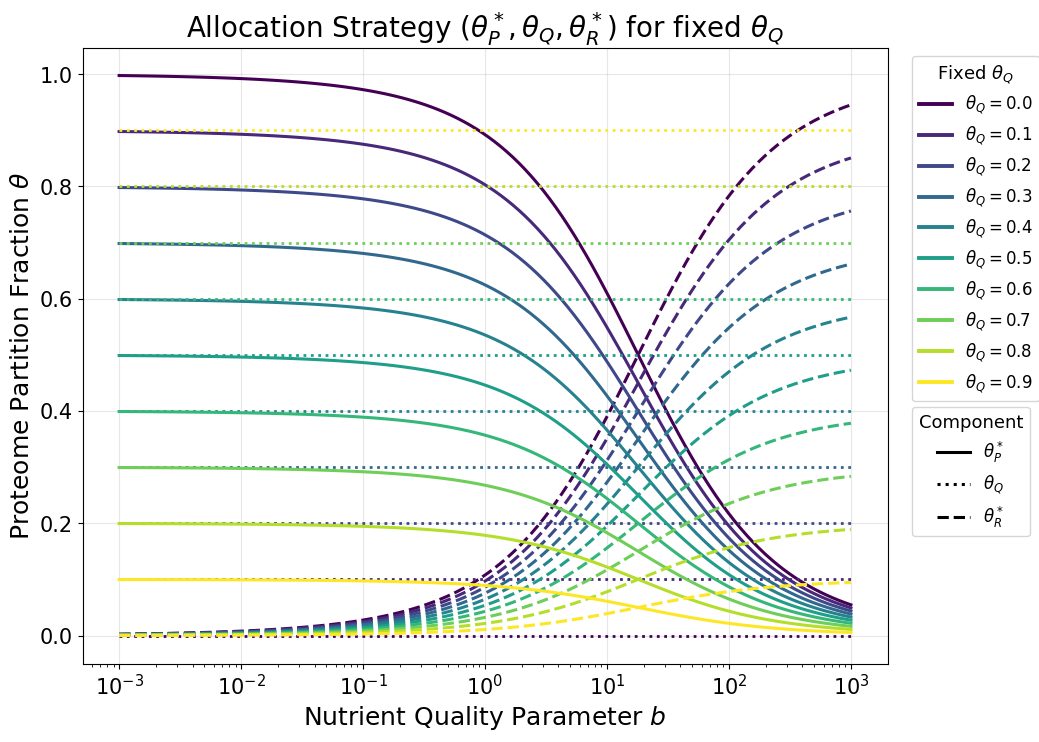

In [7]:
from matplotlib.lines import Line2D

# ============================================================
# Plot theta_P, theta_Q, theta_R together
# for theta_Q = 0.0, 0.1, ..., 0.9
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))   # wider figure
colors = plt.cm.viridis(np.linspace(0, 1, len(thetaQ_list)))

for c, theta_Q_i in zip(colors, thetaQ_list):
    if theta_Q_i not in multi_thetaQ_results:
        continue

    data_i = multi_thetaQ_results[theta_Q_i]
    b_i = data_i["b"]
    thetaP_i = data_i["thetaP_num"]
    thetaR_i = data_i["thetaR_num"]
    thetaQ_i_arr = np.full_like(b_i, theta_Q_i)

    # theta_P^*(b)
    ax.plot(b_i, thetaP_i, color=c, lw=2.2, ls='-')

    # theta_Q (constant)
    ax.plot(b_i, thetaQ_i_arr, color=c, lw=2.0, ls=':')

    # theta_R^*(b)
    ax.plot(b_i, thetaR_i, color=c, lw=2.2, ls='--')

ax.set_xscale('log')
ax.set_xlabel(r'Nutrient Quality Parameter $b$', fontsize=18)
ax.set_ylabel(r'Proteome Partition Fraction $\theta$', fontsize=18)
ax.set_title(r'Allocation Strategy $(\theta_P^*, \theta_Q, \theta_R^*)$ for fixed $\theta_Q$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.grid(True, alpha=0.3)

# Legend 1: colors correspond to theta_Q values
color_handles = [
    Line2D([0], [0], color=c, lw=2.8, label=fr'$\theta_Q={theta_Q_i:.1f}$')
    for c, theta_Q_i in zip(colors, thetaQ_list)
]

# Legend 2: line styles correspond to components
style_handles = [
    Line2D([0], [0], color='black', lw=2.2, ls='-',  label=r'$\theta_P^*$'),
    Line2D([0], [0], color='black', lw=2.2, ls=':',  label=r'$\theta_Q$'),
    Line2D([0], [0], color='black', lw=2.2, ls='--', label=r'$\theta_R^*$'),
]

legend1 = ax.legend(
    handles=color_handles,
    title=r'Fixed $\theta_Q$',
    fontsize=12,
    title_fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    frameon=True
)
ax.add_artist(legend1)

ax.legend(
    handles=style_handles,
    title='Component',
    fontsize=12,
    title_fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.43),
    frameon=True
)

# Reserve space on the right for the legends
fig.subplots_adjust(right=0.7)

plt.show()

# Stacked Plot for Proteome Partition

max deviation from 1 in optimized fractions: 2.220446049250313e-16


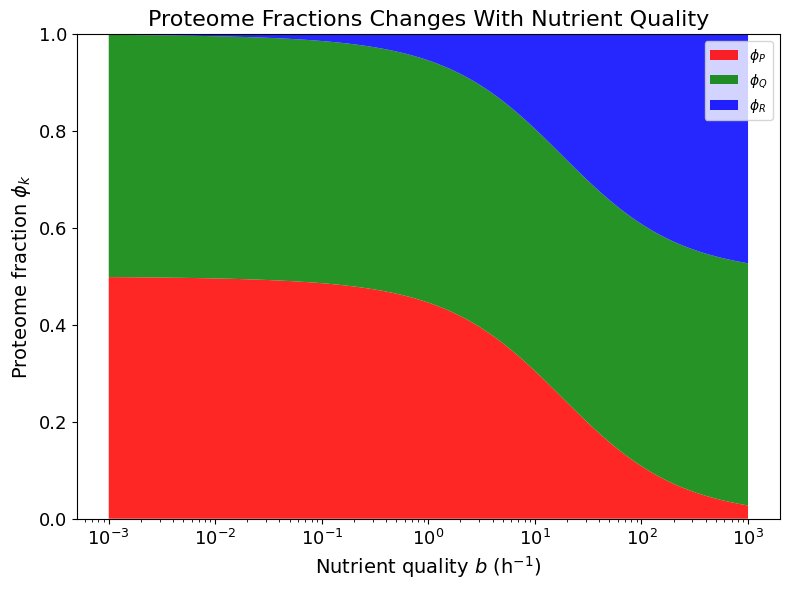

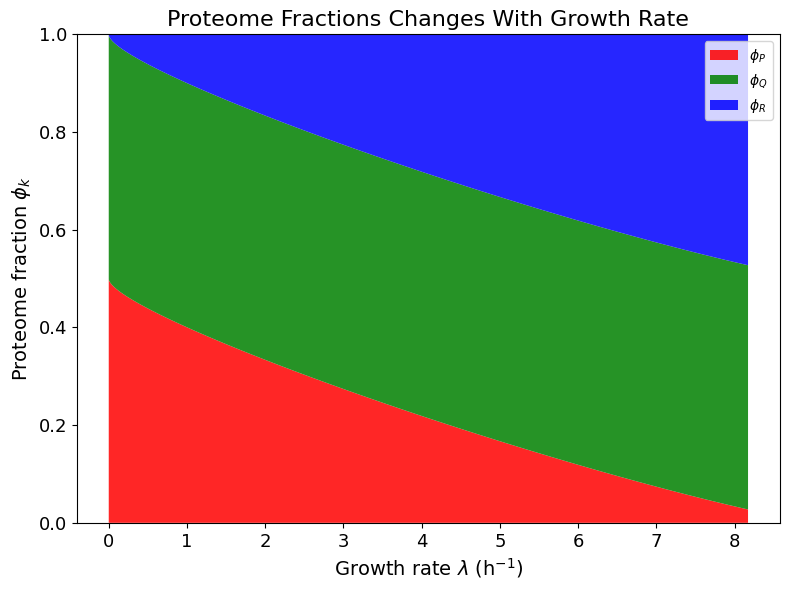

In [8]:
# ============================================================
# Proteome fractions for stacked plots
# Current two-sector model: theta_Q = 0
# ============================================================
thetaQ_arr = np.zeros_like(thetaP_arr)   # replace with actual thetaQ_arr in 3-sector case
thetaQ_arr.fill(theta_Q)   # fill with the fixed theta_Q value for the HK model

# Safety check: they should sum to 1
theta_sum_arr = thetaP_arr + thetaQ_arr + thetaR_arr
print("max deviation from 1 in optimized fractions:",
      np.max(np.abs(theta_sum_arr - 1.0)))

# ============================================================
# Plot: stacked proteome fractions versus b
# ============================================================
plt.figure(figsize=(8, 6))

plt.stackplot(
    b_arr,
    thetaP_arr,
    thetaQ_arr,
    thetaR_arr,
    colors=['red', 'green', 'blue'],
    alpha=0.85,
    labels=[r'$\phi_P$', r'$\phi_Q$', r'$\phi_R$']
)

plt.xscale('log')
plt.xlabel(r'Nutrient quality $b$ (h$^{-1}$)', fontsize=label_size)
plt.ylabel(r'Proteome fraction $\phi_k$', fontsize=label_size)
plt.title(r'Proteome Fractions Changes With Nutrient Quality', fontsize=title_size)
plt.ylim(0, 1.0)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


# ============================================================
# Plot: stacked proteome fractions versus lambda
# ============================================================
idx_lam = np.argsort(lambda_arr)

lambda_sorted = lambda_arr[idx_lam]
thetaP_sorted = thetaP_arr[idx_lam]
thetaQ_sorted = thetaQ_arr[idx_lam]
thetaR_sorted = thetaR_arr[idx_lam]

plt.figure(figsize=(8, 6))

plt.stackplot(
    lambda_sorted,
    thetaP_sorted,
    thetaQ_sorted,
    thetaR_sorted,
    colors=['red', 'green', 'blue'],
    alpha=0.85,
    labels=[r'$\phi_P$', r'$\phi_Q$', r'$\phi_R$']
)

plt.xlabel(r'Growth rate $\lambda$ (h$^{-1}$)', fontsize=label_size)
plt.ylabel(r'Proteome fraction $\phi_k$', fontsize=label_size)
plt.title(r'Proteome Fractions Changes With Growth Rate', fontsize=title_size)
plt.ylim(0, 1.0)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# An Examples With Six Sectors

------------------------------
Running discrete optimization for HK grid...


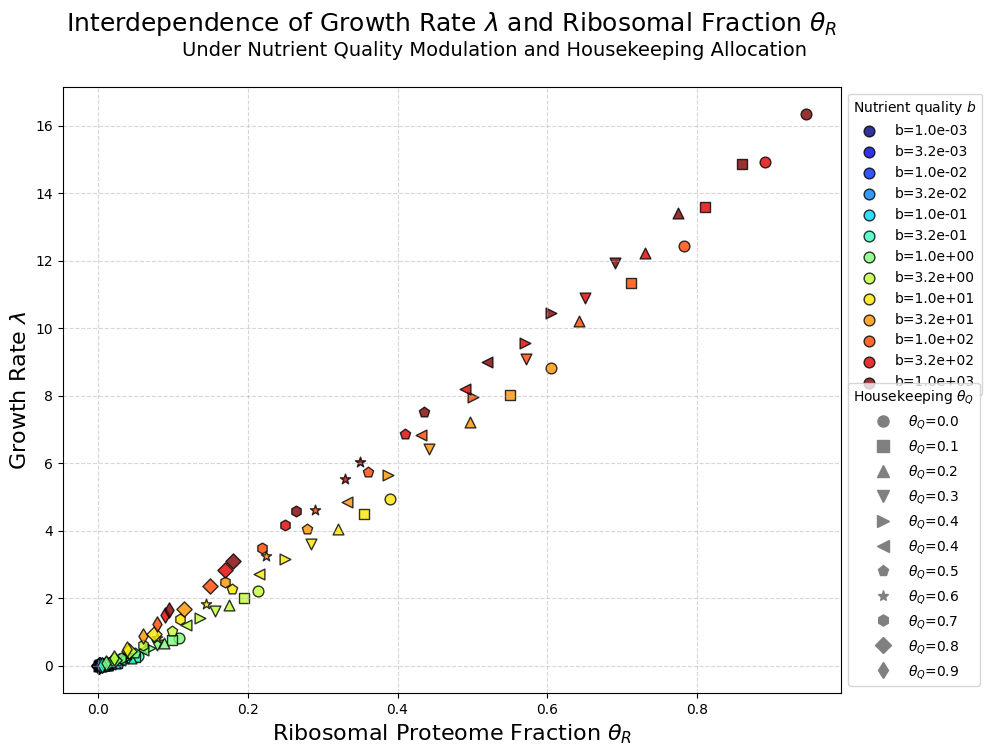

In [9]:
# --- Discrete Grid Analysis: HK model on a (b, theta_Q) grid ---

print("-" * 30)
print("Running discrete optimization for HK grid...")

# Define grid (11 x 13 points)
N_thetaQ = 10
N_b = 12
thetaQ_grid = np.linspace(0.0, 0.9, N_thetaQ + 1)
b_grid = np.logspace(np.log10(b_min), np.log10(b_max), N_b + 1)

# Safety check: this cell uses the theta_Q optimizer defined in earlier HK cells
if "optimize_for_b_softmax_HK_thetaQ" not in globals():
    raise NameError(
        "optimize_for_b_softmax_HK_thetaQ is not defined. "
        "Run the earlier HK theta_Q cell first."
    )

# Run optimization for all grid points
results_hk_grid = []
for b_val in b_grid:
    row = Parallel(n_jobs=-1)(
        delayed(optimize_for_b_softmax_HK_thetaQ)(b_val, theta_Q_val)
        for theta_Q_val in thetaQ_grid
    )

    # Keep a rectangular array shape even if any point fails
    row = [r if r is not None else np.full(8, np.nan) for r in row]
    results_hk_grid.append(row)

results_hk_grid = np.array(results_hk_grid)  # Shape (N_b+1, N_thetaQ+1, 8)

# Markers for each theta_Q value
markers = ['o', 's', '^', 'v', '>', '<', 'p', '*', 'h', 'D', 'd', '1', '2', '3', '4', '+', 'x', 'X', 'P', '8', 'H']
# Colors for each b value
colors = plt.cm.jet(np.linspace(0, 1, N_b + 1))

plt.figure(figsize=(10, 8))

for i, b_val in enumerate(b_grid):
    for j, theta_Q_val in enumerate(thetaQ_grid):
        # results_hk_grid[i, j] matches b_grid[i] and thetaQ_grid[j]
        # index 2 is theta_R, index 7 is lambda in the HK result vector
        thR = results_hk_grid[i, j, 2]
        lam = results_hk_grid[i, j, 7]

        if not (np.isfinite(thR) and np.isfinite(lam)):
            continue

        # Only add one label per b value for the color legend
        label = f'b={b_val:.1e}' if j == 0 else ""

        plt.scatter(
            thR,
            lam,
            color=colors[i],
            marker=markers[j],
            s=60,
            alpha=0.8,
            edgecolors='black',
            label=label
        )

# Add custom legend for markers (theta_Q values)
from matplotlib.lines import Line2D
marker_legend_elements = [
    Line2D(
        [0], [0], marker=markers[j], color='gray', linestyle='None',
        label=fr'$\theta_Q$={thetaQ_grid[j]:.1f}', markersize=8
    )
    for j in range(len(thetaQ_grid))
]

# First legend (b values / colors)
leg1 = plt.legend(title='Nutrient quality $b$', loc='upper left', bbox_to_anchor=(1, 1))
# Second legend (theta_Q / markers)
plt.gca().add_artist(leg1)
plt.legend(handles=marker_legend_elements, title='Housekeeping $\\theta_Q$', loc='lower left', bbox_to_anchor=(1, 0))

plt.title(r'Interdependence of Growth Rate $\lambda$ and Ribosomal Fraction $\theta_R$', fontsize=18, pad=40)
plt.suptitle('Under Nutrient Quality Modulation and Housekeeping Allocation', fontsize=14, y=0.90)
plt.xlabel(r'Ribosomal Proteome Fraction $\theta_R$', fontsize=16)
plt.ylabel(r'Growth Rate $\lambda$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Lassig Figure

max deviation from theta_P + theta_Q + theta_R = 1: 2.220446049250313e-16
q_HK = sqrt(a*k) = 1.48324


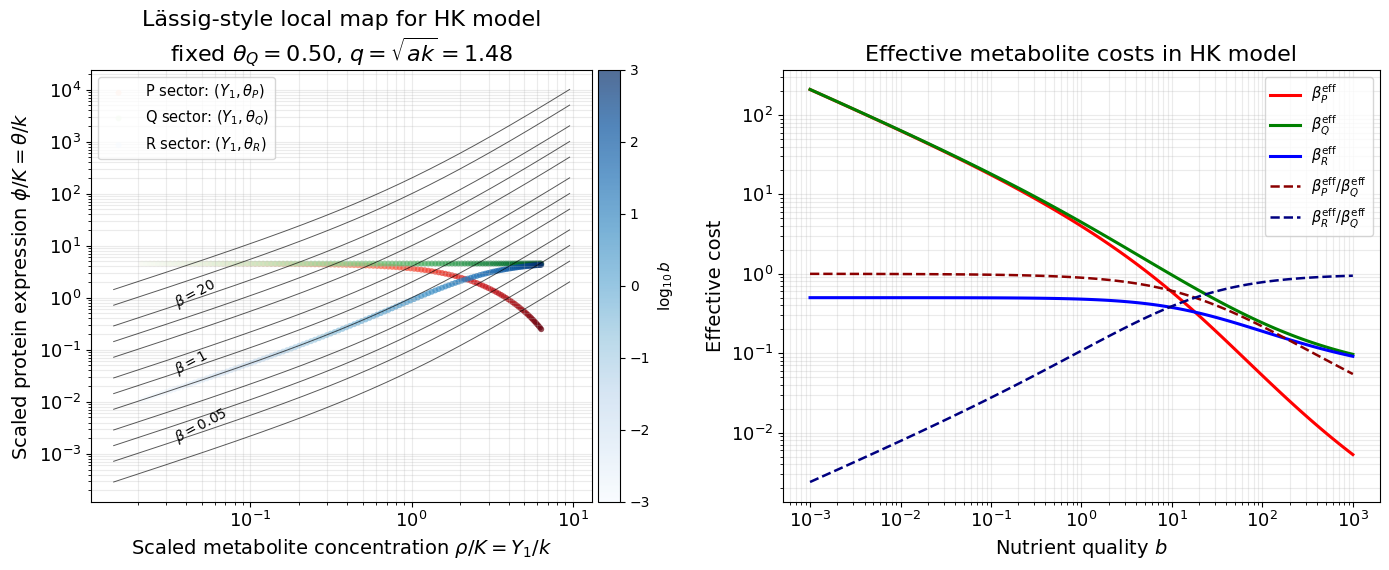

,b,theta_P,theta_Q,theta_R,lambda,x = Y1/k,y_P = thetaP/k,y_Q = thetaQ/k,y_R = thetaR/k,betaP_eff,betaQ_eff,betaR_eff
0,0.001000,0.498805,0.5,0.001195,0.000498,0.021270,4.534594,4.545455,0.010861,208.749622,209.249595,0.499974
1,0.001123,0.498733,0.5,0.001267,0.000559,0.022538,4.533932,4.545455,0.011523,196.733816,197.233798,0.499982
2,0.001261,0.498655,0.5,0.001345,0.000627,0.023882,4.533229,4.545455,0.012225,185.392225,185.892194,0.499969
3,0.001417,0.498573,0.5,0.001427,0.000704,0.025305,4.532483,4.545455,0.012972,174.693238,175.193206,0.499968
4,0.001591,0.498486,0.5,0.001514,0.000791,0.026813,4.531690,4.545455,0.013765,164.598707,165.098676,0.499969
5,0.001787,0.498393,0.5,0.001607,0.000888,0.028410,4.530847,4.545455,0.014608,155.072595,155.572555,0.499960
6,0.002007,0.498295,0.5,0.001705,0.000997,0.030103,4.529952,4.545455,0.015503,146.084558,146.584508,0.499950
7,0.002254,0.498190,0.5,0.001810,0.001119,0.031896,4.529000,4.545455,0.016455,137.605045,138.104991,0.499946
8,0.002531,0.498079,0.5,0.001921,0.001256,0.033795,4.527988,4.545455,0.017466,129.604592,130.104532,0.499940
9,0.002843,0.497960,0.5,0.002040,0.001410,0.035807,4.526913,4.545455,0.018542,122.055731,122.555661,0.499930


In [10]:
# ============================================================
# Lässig-style local metabolite–enzyme diagnostic plot
# for the three-sector HK model with fixed theta_Q = 0.5
#
# Adaptation note:
# In the HK model there is one internal metabolite pool Y1 and
# one Michaelis-Menten translation step with parameter pair (a, k).
# The three protein sectors P, Q, R are all synthesized from the
# same precursor pool Y1, so the natural analogue of the Lässig
# plot is to use the common scaled metabolite coordinate
#
#     x = Y1 / k
#
# and three scaled protein-expression coordinates
#
#     y_P = theta_P / k,   y_Q = theta_Q / k,   y_R = theta_R / k
#
# with effective costs
#
#     beta_eff = phi / [Y1 * (1 + Y1/k)] .
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Styling fallback
# -----------------------------
tick_size_local  = globals().get("tick_size", 12)
label_size_local = globals().get("label_size", 14)
title_size_local = globals().get("title_size", 16)

# -----------------------------
# Fixed HK proteome fractions
# -----------------------------
thetaQ_arr = np.full_like(b_arr, theta_Q)

# Safety check
theta_sum_arr = thetaP_arr + thetaQ_arr + thetaR_arr
print("max deviation from theta_P + theta_Q + theta_R = 1:",
      np.max(np.abs(theta_sum_arr - 1.0)))

# -----------------------------
# Scaled coordinates
# common metabolite coordinate x = rho/K = Y1/k
# -----------------------------
x_HK = Y1_arr / k

y_P = thetaP_arr / k
y_Q = thetaQ_arr / k
y_R = thetaR_arr / k

# -----------------------------
# Effective costs
# y = beta * x * (1 + x)  =>  beta = phi / [rho (1 + rho/K)]
# -----------------------------
eps = 1e-300
denom = np.maximum(Y1_arr * (1.0 + Y1_arr / k), eps)

betaP_eff = thetaP_arr / denom
betaQ_eff = thetaQ_arr / denom
betaR_eff = thetaR_arr / denom

# -----------------------------
# Local biochemical-quality parameter
# In this HK reduction there is one MM translation quality.
# -----------------------------
q_HK = np.sqrt(a * k)
print(f"q_HK = sqrt(a*k) = {q_HK:.6g}")

# -----------------------------
# Masks for log plots
# -----------------------------
mask = (
    (b_arr > 0) &
    (x_HK > 0) &
    np.isfinite(b_arr) &
    np.isfinite(x_HK) &
    np.isfinite(y_P) &
    np.isfinite(y_Q) &
    np.isfinite(y_R)
)

# -----------------------------
# Family of beta-curves: y = beta x (1 + x)
# -----------------------------
x_min = np.min(x_HK[mask]) / 1.5
x_max = np.max(x_HK[mask]) * 1.5
x_grid = np.logspace(np.log10(x_min), np.log10(x_max), 600)

beta_levels = [0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# ============================================================
# Panel 1: Lässig-style local map
# ============================================================
ax = axes[0]

for beta in beta_levels:
    y_grid = beta * x_grid * (1.0 + x_grid)
    ax.plot(x_grid, y_grid, color='black', lw=0.7, alpha=0.65)

# Scatter each sector against the common metabolite pool
scP = ax.scatter(
    x_HK[mask], y_P[mask],
    c=np.log10(b_arr[mask]), cmap='Reds',
    s=18, alpha=0.70, edgecolors='none',
    label=r'P sector: $(Y_1,\theta_P)$'
)

scQ = ax.scatter(
    x_HK[mask], y_Q[mask],
    c=np.log10(b_arr[mask]), cmap='Greens',
    s=18, alpha=0.70, edgecolors='none',
    label=r'Q sector: $(Y_1,\theta_Q)$'
)

scR = ax.scatter(
    x_HK[mask], y_R[mask],
    c=np.log10(b_arr[mask]), cmap='Blues',
    s=18, alpha=0.70, edgecolors='none',
    label=r'R sector: $(Y_1,\theta_R)$'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Scaled metabolite concentration $\rho/K = Y_1/k$', fontsize=label_size_local)
ax.set_ylabel(r'Scaled protein expression $\phi/K = \theta/k$', fontsize=label_size_local)
ax.set_title(
    r'Lässig-style local map for HK model' + '\n'
    + rf'fixed $\theta_Q={theta_Q:.2f}$, '
    + rf'$q=\sqrt{{ak}}={q_HK:.3g}$',
    fontsize=title_size_local
)
ax.tick_params(axis='both', which='major', labelsize=tick_size_local)
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=10.5, loc='best')

# label a few beta-curves
for beta in [0.05, 1, 20]:
    x_lab = x_grid[int(0.12 * len(x_grid))]
    y_lab = beta * x_lab * (1.0 + x_lab)
    ax.text(x_lab * 1.05, y_lab * 1.05, rf'$\beta={beta:g}$',
            fontsize=10, rotation=28)

cb = plt.colorbar(scR, ax=ax, pad=0.01)
cb.set_label(r'$\log_{10} b$', fontsize=11)
cb.ax.tick_params(labelsize=10)

# ============================================================
# Panel 2: effective costs vs nutrient quality
# ============================================================
ax = axes[1]

ax.plot(b_arr[mask], betaP_eff[mask], lw=2.2, color='red',
        label=r'$\beta_P^{\mathrm{eff}}$')
ax.plot(b_arr[mask], betaQ_eff[mask], lw=2.2, color='green',
        label=r'$\beta_Q^{\mathrm{eff}}$')
ax.plot(b_arr[mask], betaR_eff[mask], lw=2.2, color='blue',
        label=r'$\beta_R^{\mathrm{eff}}$')

# Ratios to Q are often useful in the HK model
ratio_mask = mask & (betaQ_eff > 0)
ax.plot(
    b_arr[ratio_mask],
    betaP_eff[ratio_mask] / betaQ_eff[ratio_mask],
    lw=1.8, ls='--', color='darkred',
    label=r'$\beta_P^{\mathrm{eff}}/\beta_Q^{\mathrm{eff}}$'
)
ax.plot(
    b_arr[ratio_mask],
    betaR_eff[ratio_mask] / betaQ_eff[ratio_mask],
    lw=1.8, ls='--', color='navy',
    label=r'$\beta_R^{\mathrm{eff}}/\beta_Q^{\mathrm{eff}}$'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Nutrient quality $b$', fontsize=label_size_local)
ax.set_ylabel(r'Effective cost', fontsize=label_size_local)
ax.set_title(r'Effective metabolite costs in HK model', fontsize=title_size_local)
ax.tick_params(axis='both', which='major', labelsize=tick_size_local)
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=10.5, loc='best')

plt.tight_layout()
plt.show()

# ============================================================
# Optional compact summary table
# ============================================================
diag_df_hk = pd.DataFrame({
    "b": b_arr,
    "theta_P": thetaP_arr,
    "theta_Q": thetaQ_arr,
    "theta_R": thetaR_arr,
    "lambda": lambda_arr,
    "x = Y1/k": x_HK,
    "y_P = thetaP/k": y_P,
    "y_Q = thetaQ/k": y_Q,
    "y_R = thetaR/k": y_R,
    "betaP_eff": betaP_eff,
    "betaQ_eff": betaQ_eff,
    "betaR_eff": betaR_eff,
})
display(diag_df_hk.head(10))